# EDA — Detección de Fraude en Tarjetas de Crédito

**Dataset:** `credit_card_frauds.csv`  
**Objetivo:** Clasificación binaria — predecir si una transacción es fraudulenta (`is_fraud = 1`) o legítima (`is_fraud = 0`).  
**Estructura del notebook:**
1. Librerías y carga de datos
2. División train/test (**primero**, para evitar data leakage)
3. Inspección general
4. Ingeniería de variables temporales
5. Análisis univariable — variables numéricas
6. Tratamiento de outliers
7. Análisis univariable — variables categóricas
8. Análisis bivariable — correlaciones numéricas (Pearson, Spearman, Información Mutua)
9. Análisis bivariable — variables categóricas vs target (Chi², V de Cramer)
10. Selección y eliminación de variables
11. Encoding y escalado final
12. Guardado de datasets procesados

## 1. Librerías

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from category_encoders import BinaryEncoder


# Estilo de los gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 2. Carga de datos y división train/test

> **Importante — Data Leakage:** La división train/test se realiza **antes** de cualquier exploración o transformación. Esto garantiza que las estadísticas del conjunto de test no contaminen las decisiones tomadas durante el análisis y el preprocesado.

In [29]:
df_raw = pd.read_csv('../data/credit_card_frauds.csv')
print(f'Dimensiones del dataset original: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')

Dimensiones del dataset original: 339,607 filas × 15 columnas


In [30]:
X = df_raw.drop('is_fraud', axis=1)
y = df_raw['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # Mantenemos la proporción de fraude en ambos conjuntos
)

# Reconstruimos DataFrames completos para el análisis
df      = pd.concat([X_train, y_train], axis=1).copy()
df_test = pd.concat([X_test,  y_test],  axis=1).copy()

print(f'Train: {df.shape[0]:,} filas  ({df.shape[0]/df_raw.shape[0]:.0%})')
print(f'Test:  {df_test.shape[0]:,} filas  ({df_test.shape[0]/df_raw.shape[0]:.0%})')

Train: 271,685 filas  (80%)
Test:  67,922 filas  (20%)


## 3. Inspección general

In [31]:
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
179685,2020-02-01 13:21:27,"Streich, Rolfson and Wilderman",kids_pets,24.79,Hooper,NE,41.6414,-96.5232,1745,"Engineer, automotive",1973-12-26,e77c97ca17e3fbc26a50613965b1535d,40.751034,-97.116876,0
138301,2019-11-17 21:27:54,Wilkinson Lt,entertainment,12.40,Hooper,NE,41.6414,-96.5232,1745,"Engineer, automotive",1973-12-26,e386b85fb56052f4a56624aadb7d20fd,41.826237,-97.070998,0
200559,2020-03-30 10:30:24,"Moen, Reinger and Murphy",grocery_pos,108.34,Hatch,UT,37.7175,-112.4777,258,Geoscientist,1961-11-24,df5605c760137917772ebc3d00e302de,37.830209,-112.288001,0
39697,2019-04-20 06:20:42,"Greenfelder, Bartoletti and Davis",misc_net,179.56,Indian Wells,CA,33.7163,-116.3381,4677,Learning mentor,1955-05-06,c536e8ae3366dac06d573fb330032871,32.849351,-116.551486,0
84427,2019-07-22 05:34:32,"Ruecker, Beer and Collie",shopping_net,9.17,Carlotta,CA,40.5070,-123.9743,1139,"Therapist, occupational",1951-01-15,23f46db383c0b293201808909fe6458a,40.492905,-124.469651,0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 271685 entries, 179685 to 109523
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  271685 non-null  object 
 1   merchant               271685 non-null  object 
 2   category               271685 non-null  object 
 3   amt                    271685 non-null  float64
 4   city                   271685 non-null  object 
 5   state                  271685 non-null  object 
 6   lat                    271685 non-null  float64
 7   long                   271685 non-null  float64
 8   city_pop               271685 non-null  int64  
 9   job                    271685 non-null  object 
 10  dob                    271685 non-null  object 
 11  trans_num              271685 non-null  object 
 12  merch_lat              271685 non-null  float64
 13  merch_long             271685 non-null  float64
 14  is_fraud               271685 non-nu

In [33]:
# Resumen estadístico con percentiles adicionales para detectar distribuciones asimétricas
df.describe(percentiles=[.25, .5, .75, .90, .95, .99]).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
amt,271685.0,70.715613,158.413544,1.000000,9.610000,46.590000,83.370000,139.560000,199.318000,5.487280e+02,1.683708e+04
lat,271685.0,39.722564,5.100956,20.027100,36.715400,39.617100,41.710000,45.671000,47.497400,4.888780e+01,6.669330e+01
long,271685.0,-110.621040,12.669305,-165.672300,-120.093600,-111.029200,-100.621500,-93.628900,-91.891200,-9.038700e+01,-8.962870e+01
city_pop,271685.0,107504.690115,293661.410436,46.000000,493.000000,1661.000000,35705.000000,320420.000000,841711.000000,1.312922e+06,2.383912e+06
merch_lat,271685.0,39.722237,5.136503,19.027785,36.820109,39.590181,42.193976,45.778557,47.683802,4.970473e+01,6.751027e+01
merch_long,271685.0,-110.620480,12.683059,-166.671575,-119.835779,-111.031084,-100.318240,-93.494307,-91.885283,-8.996280e+01,-8.862920e+01
is_fraud,271685.0,0.005249,0.072258,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00


In [34]:
# Valores nulos por columna
nulos = df.isnull().sum()
print('--- Valores nulos por columna ---')
print(nulos[nulos >= 0].to_string())
print(f'\nTotal de celdas con valores nulos: {nulos.sum()}')

--- Valores nulos por columna ---
trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0

Total de celdas con valores nulos: 0


--- Variable objetivo: is_fraud ---
  Legítimas (0): 270,259  (99.48%)
  Fraudes   (1):   1,426  (0.52%)

Ratio de desbalanceo: 1 fraude por cada 189 transacciones legítimas


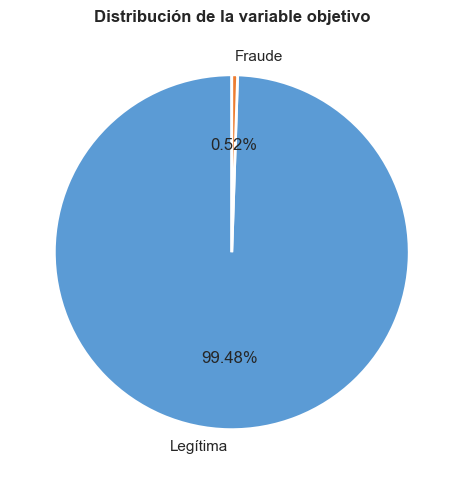

In [35]:
# Distribución de la variable objetivo
conteo = df['is_fraud'].value_counts()
pct    = df['is_fraud'].value_counts(normalize=True) * 100

print('--- Variable objetivo: is_fraud ---')
print(f'  Legítimas (0): {conteo[0]:>7,}  ({pct[0]:.2f}%)')
print(f'  Fraudes   (1): {conteo[1]:>7,}  ({pct[1]:.2f}%)')
print(f'\nRatio de desbalanceo: 1 fraude por cada {conteo[0]//conteo[1]} transacciones legítimas')

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(conteo, labels=['Legítima', 'Fraude'], autopct='%1.2f%%',
       colors=['#5B9BD5', '#ED7D31'], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Distribución de la variable objetivo', fontweight='bold')
plt.tight_layout()
plt.show()

> **Observación:** El dataset presenta un fuerte desbalanceo (~0.52% de fraudes). Esto deberá tenerse en cuenta en el notebook de modelado aplicando técnicas como SMOTE o ajustando `class_weight`.

## 4. Ingeniería de variables temporales

Extraemos variables nuevas a partir de las columnas de fecha, que sustituirán a las originales con mayor poder predictivo.

In [36]:
for d in [df, df_test]:
    d['trans_date_trans_time'] = pd.to_datetime(d['trans_date_trans_time'])
    d['dob']                   = pd.to_datetime(d['dob'])

    # Edad del titular en el momento de la transacción
    d['age']        = (d['trans_date_trans_time'] - d['dob']).dt.days // 365

    # Variables temporales de la transacción
    d['hour']       = d['trans_date_trans_time'].dt.hour
    d['day_of_week']= d['trans_date_trans_time'].dt.dayofweek   # 0=Lun, 6=Dom
    d['month']      = d['trans_date_trans_time'].dt.month
    d['is_weekend'] = d['trans_date_trans_time'].dt.dayofweek.isin([5, 6]).astype(int)

# Eliminamos el identificador único (no aporta información predictiva)
df.drop(columns='trans_num',      inplace=True)
df_test.drop(columns='trans_num', inplace=True)

print('Nuevas variables creadas: age, hour, day_of_week, month, is_weekend')
df[['age', 'hour', 'day_of_week', 'month', 'is_weekend']].describe().T

Nuevas variables creadas: age, hour, day_of_week, month, is_weekend


,count,mean,std,min,25%,50%,75%,max
age,271685.0,47.352301,17.041163,17.0,34.0,45.0,58.0,93.0
hour,271685.0,12.811690,6.812981,0.0,7.0,14.0,19.0,23.0
day_of_week,271685.0,2.961209,2.190469,0.0,1.0,3.0,5.0,6.0
month,271685.0,7.158500,3.425476,1.0,4.0,7.0,10.0,12.0
is_weekend,271685.0,0.324350,0.468132,0.0,0.0,0.0,1.0,1.0


In [37]:
# Separamos columnas numéricas y categóricas para el análisis
numeric_cols   = df.select_dtypes(exclude='object').columns.tolist()
categoric_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f'Variables numéricas  ({len(numeric_cols)}): {numeric_cols}')
print(f'Variables categóricas ({len(categoric_cols)}): {categoric_cols}')


Variables numéricas  (14): ['trans_date_trans_time', 'amt', 'lat', 'long', 'city_pop', 'dob', 'merch_lat', 'merch_long', 'is_fraud', 'age', 'hour', 'day_of_week', 'month', 'is_weekend']
Variables categóricas (5): ['merchant', 'category', 'city', 'state', 'job']


## 5. Análisis univariable — Variables numéricas

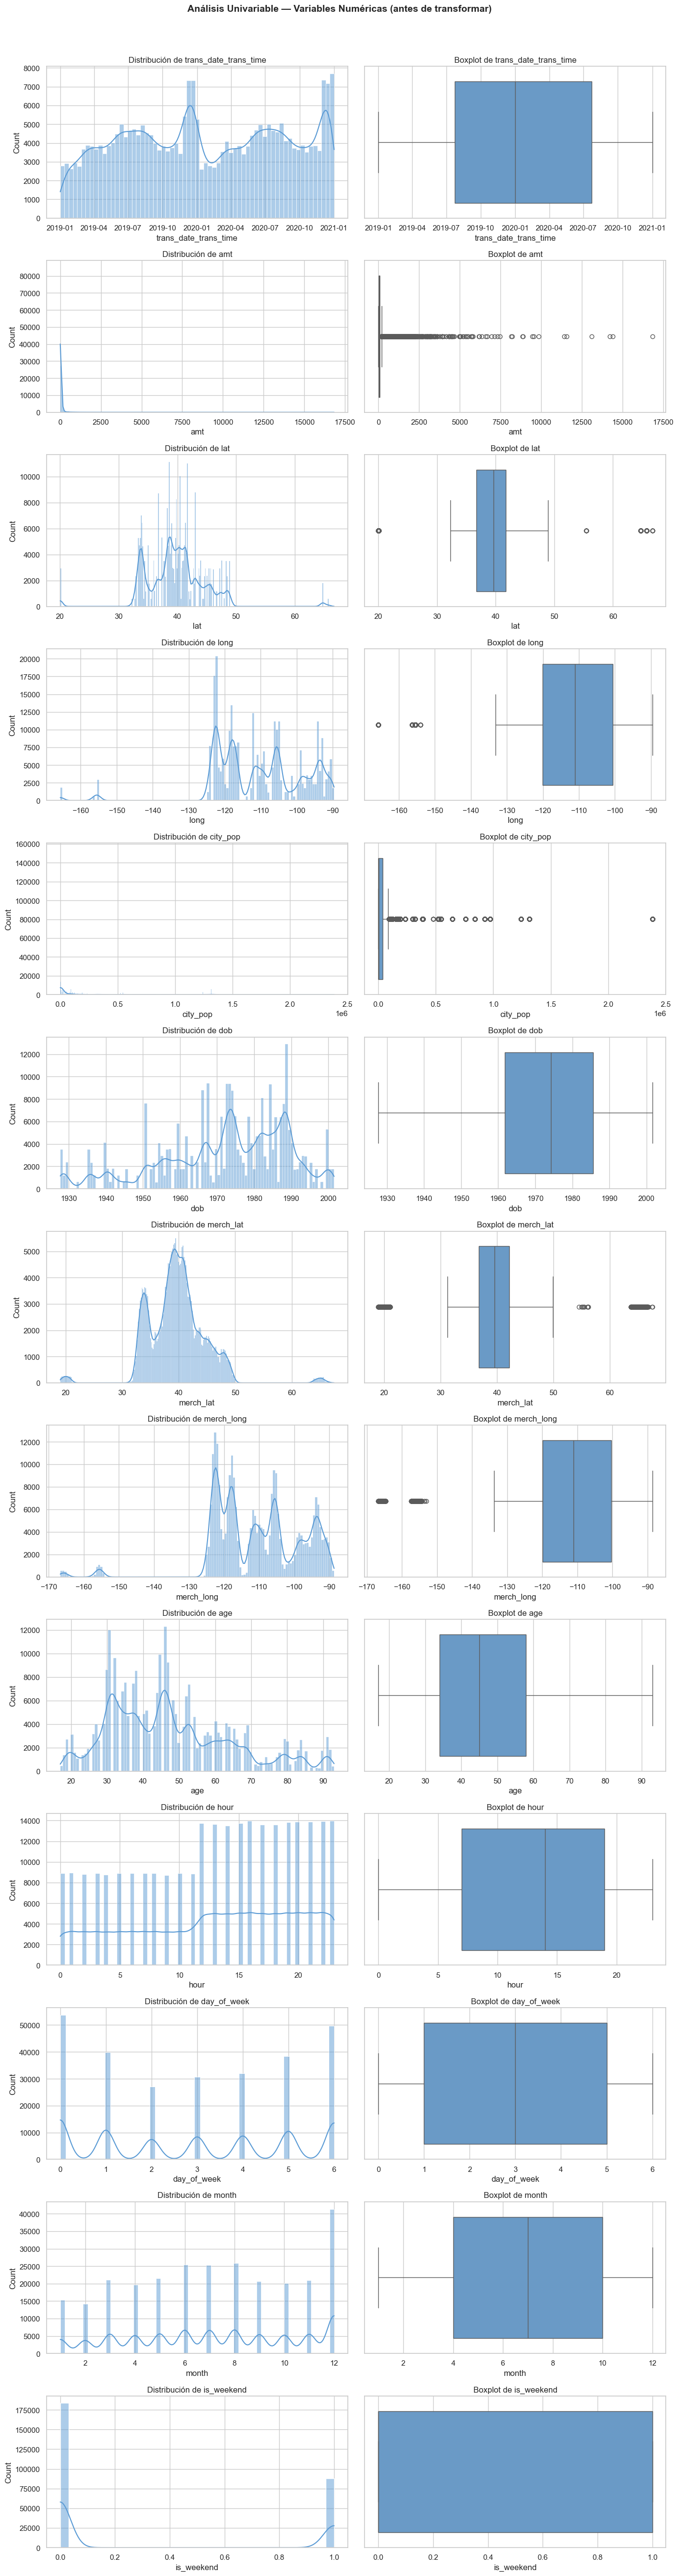

In [42]:
# Histograma de densidad + boxplot para cada variable numérica
cols_to_plot = [c for c in numeric_cols if c != 'is_fraud']

fig, axes = plt.subplots(nrows=len(cols_to_plot), ncols=2,
                         figsize=(14, 4 * len(cols_to_plot)))

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='#5B9BD5')
    axes[i, 0].set_title(f'Distribución de {col}')

    sns.boxplot(x=df[col], ax=axes[i, 1], color='#5B9BD5')
    axes[i, 1].set_title(f'Boxplot de {col}')

plt.suptitle('Análisis Univariable — Variables Numéricas (antes de transformar)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [43]:
# Resumen cuantitativo de outliers (método IQR)
print('--- Resumen de Outliers (método IQR) ---')
for col in cols_to_plot:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'  {col:<15}: {len(outliers):>6,} registros ({len(outliers)/len(df)*100:.2f}%)')

--- Resumen de Outliers (método IQR) ---
  trans_date_trans_time:      0 registros (0.00%)
  amt            : 14,532 registros (5.35%)
  lat            :  5,316 registros (1.96%)
  long           :  5,306 registros (1.95%)
  city_pop       : 52,188 registros (19.21%)
  dob            :      0 registros (0.00%)
  merch_lat      :  5,316 registros (1.96%)
  merch_long     :  5,306 registros (1.95%)
  age            :      0 registros (0.00%)
  hour           :      0 registros (0.00%)
  day_of_week    :      0 registros (0.00%)
  month          :      0 registros (0.00%)
  is_weekend     :      0 registros (0.00%)


## 6. Tratamiento de outliers

Estrategia diferenciada según el tipo de variable:

- **`amt` y `city_pop`:** Tienen una distribución muy sesgada a la derecha con muchos outliers. Aplicamos transformación logarítmica (`log1p`) para normalizar la distribución sin eliminar registros.
- **Coordenadas geográficas** (`lat`, `long`, `merch_lat`, `merch_long`): Aplicamos `RobustScaler`, que escala usando la mediana y el rango intercuartílico, minimizando el impacto de los extremos sin eliminarlos.

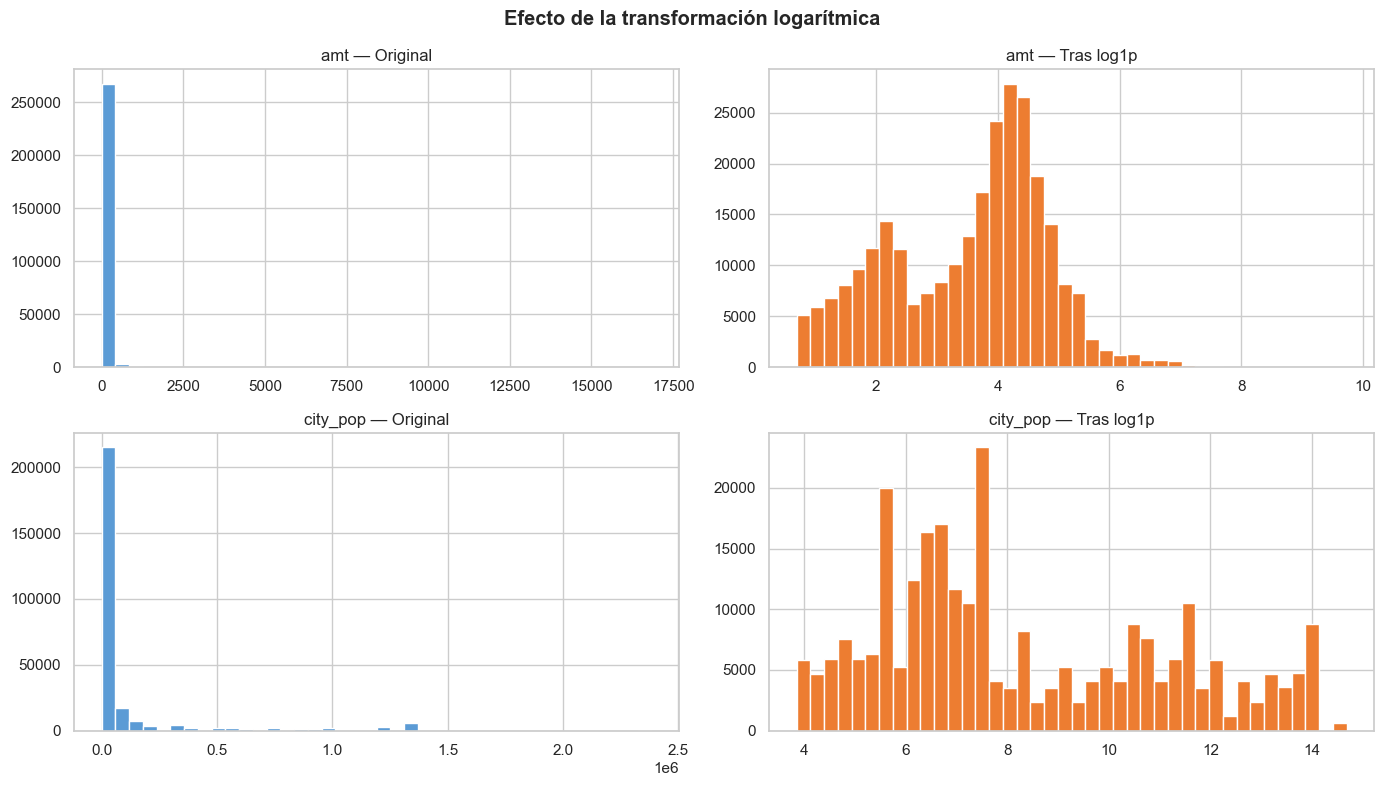

In [44]:
# Transformación logarítmica para amt y city_pop
amt_pop_cols = ['amt', 'city_pop']
df_vis = df[amt_pop_cols].copy()  # Copia para visualización comparativa

df[amt_pop_cols]      = np.log1p(df[amt_pop_cols])
df_test[amt_pop_cols] = np.log1p(df_test[amt_pop_cols])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, col in enumerate(amt_pop_cols):
    axes[i, 0].hist(df_vis[col], bins=40, color='#5B9BD5', edgecolor='white')
    axes[i, 0].set_title(f'{col} — Original')

    axes[i, 1].hist(df[col], bins=40, color='#ED7D31', edgecolor='white')
    axes[i, 1].set_title(f'{col} — Tras log1p')

plt.suptitle('Efecto de la transformación logarítmica', fontweight='bold')
plt.tight_layout()
plt.show()

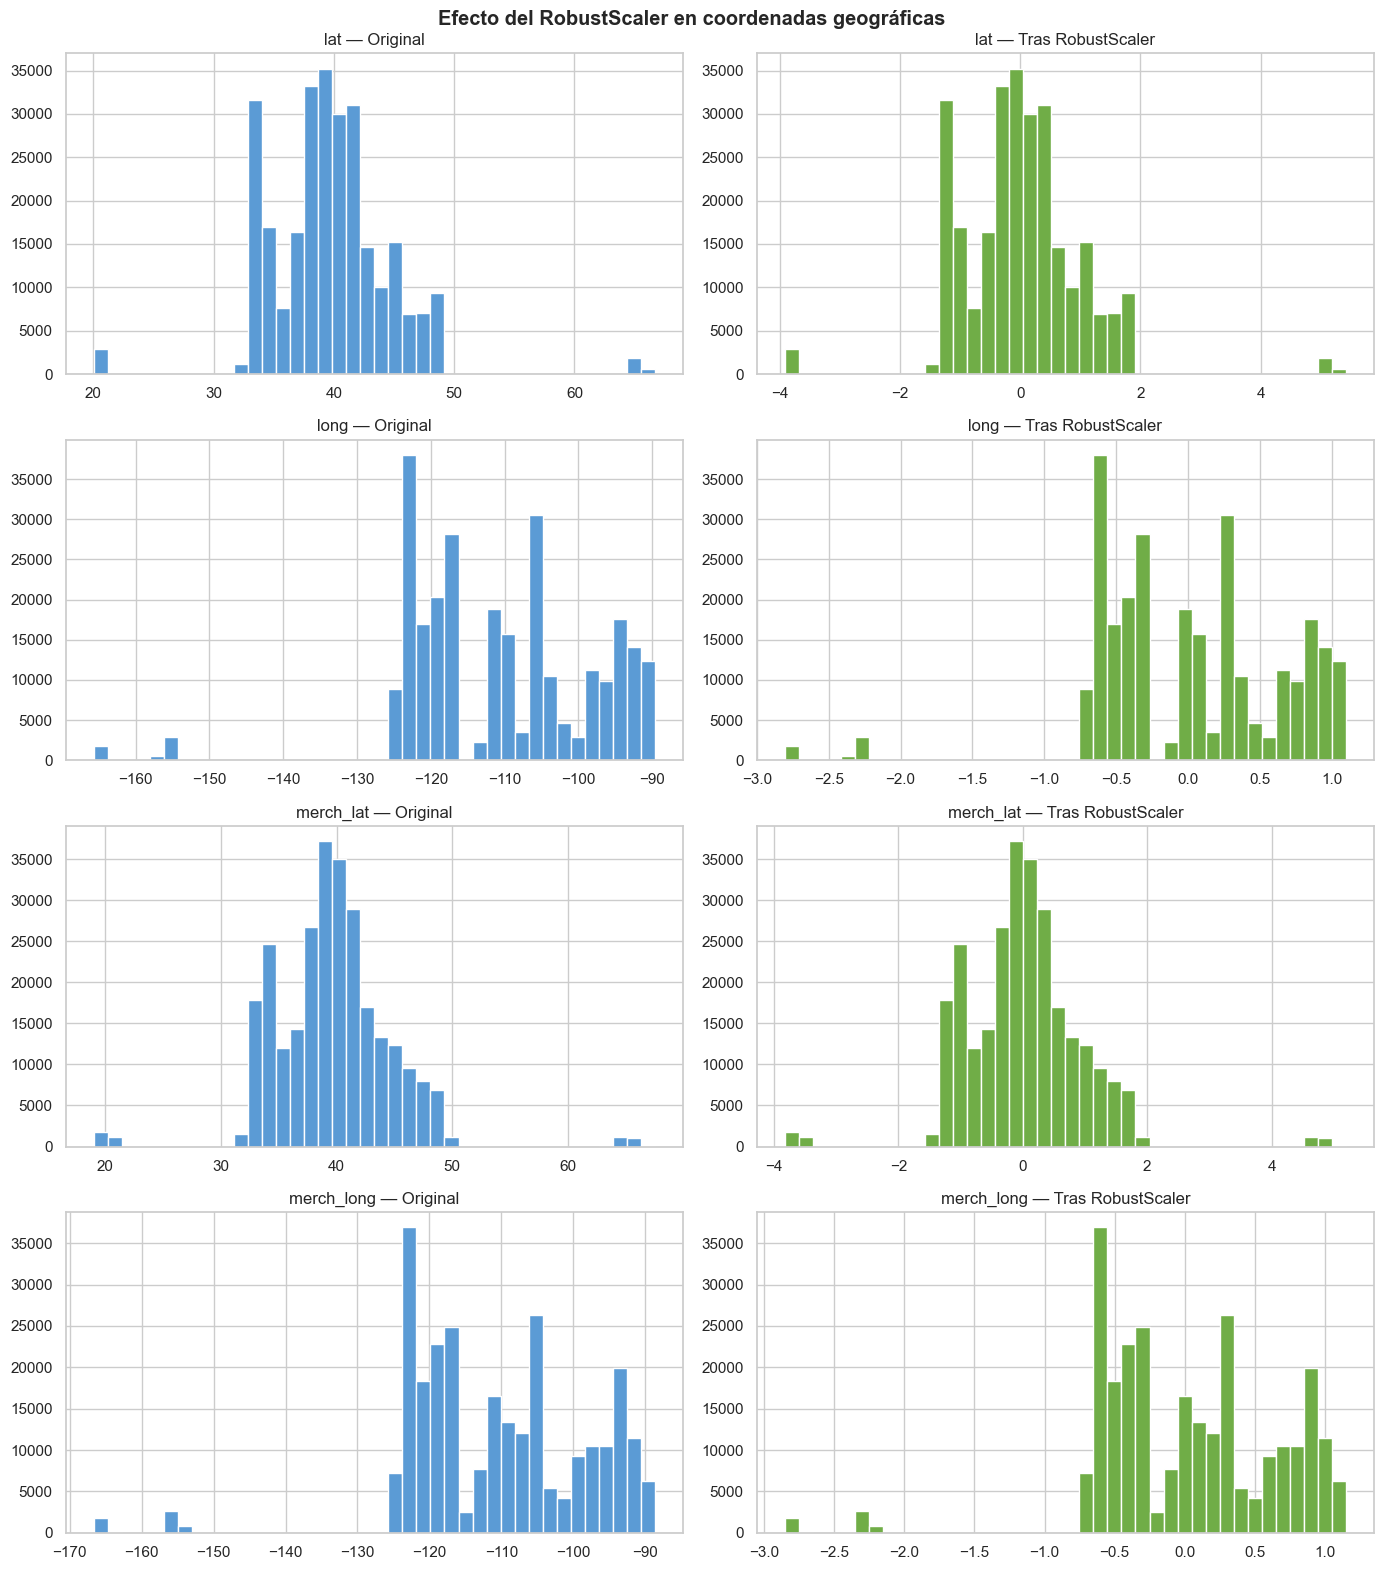

In [45]:
# RobustScaler para coordenadas geográficas
# IMPORTANTE: fit solo en train, transform en ambos (evita data leakage)
lat_long_cols = ['lat', 'long', 'merch_lat', 'merch_long']
df_vis_geo = df[lat_long_cols].copy()

robust_scaler = RobustScaler()
df[lat_long_cols]      = robust_scaler.fit_transform(df[lat_long_cols])
df_test[lat_long_cols] = robust_scaler.transform(df_test[lat_long_cols])  # Solo transform en test

fig, axes = plt.subplots(len(lat_long_cols), 2, figsize=(14, 4 * len(lat_long_cols)))
for i, col in enumerate(lat_long_cols):
    axes[i, 0].hist(df_vis_geo[col], bins=40, color='#5B9BD5', edgecolor='white')
    axes[i, 0].set_title(f'{col} — Original')

    axes[i, 1].hist(df[col], bins=40, color='#70AD47', edgecolor='white')
    axes[i, 1].set_title(f'{col} — Tras RobustScaler')

plt.suptitle('Efecto del RobustScaler en coordenadas geográficas', fontweight='bold')
plt.tight_layout()
plt.show()

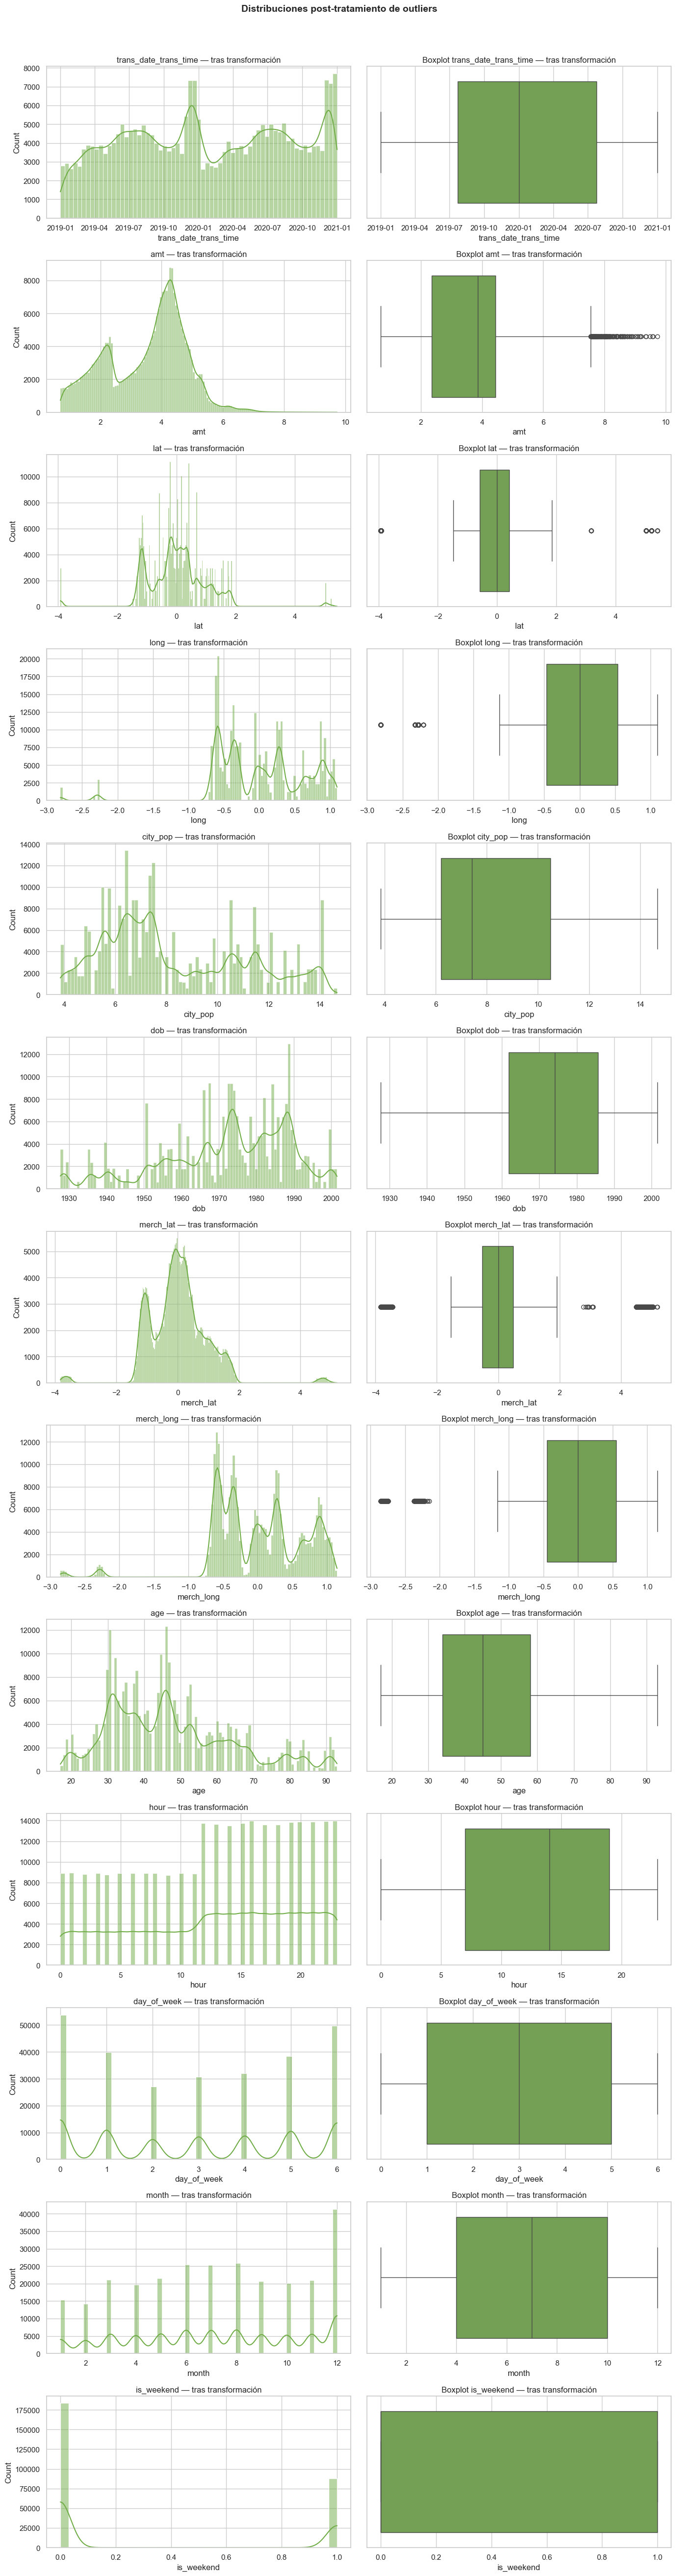

In [46]:
# Boxplots post-transformación para confirmar mejoría
cols_post = [c for c in numeric_cols if c != 'is_fraud']
fig, axes = plt.subplots(nrows=len(cols_post), ncols=2,
                         figsize=(14, 4 * len(cols_post)))

for i, col in enumerate(cols_post):
    if col not in df.columns:
        continue
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='#70AD47')
    axes[i, 0].set_title(f'{col} — tras transformación')

    sns.boxplot(x=df[col], ax=axes[i, 1], color='#70AD47')
    axes[i, 1].set_title(f'Boxplot {col} — tras transformación')

plt.suptitle('Distribuciones post-tratamiento de outliers', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Análisis univariable — Variables categóricas

Analizamos la cardinalidad y distribución de frecuencias de cada variable categórica.

In [47]:
# Cardinalidad de variables categóricas
analisis_cardinalidad = pd.DataFrame({
    'Variable':       categoric_cols,
    'Valores únicos': [df[col].nunique() for col in categoric_cols]
}).sort_values('Valores únicos', ascending=False)

print('--- Cardinalidad de Variables Categóricas ---')
print(analisis_cardinalidad.to_string(index=False))

--- Cardinalidad de Variables Categóricas ---
Variable  Valores únicos
merchant             693
    city             176
     job             163
category              14
   state              13


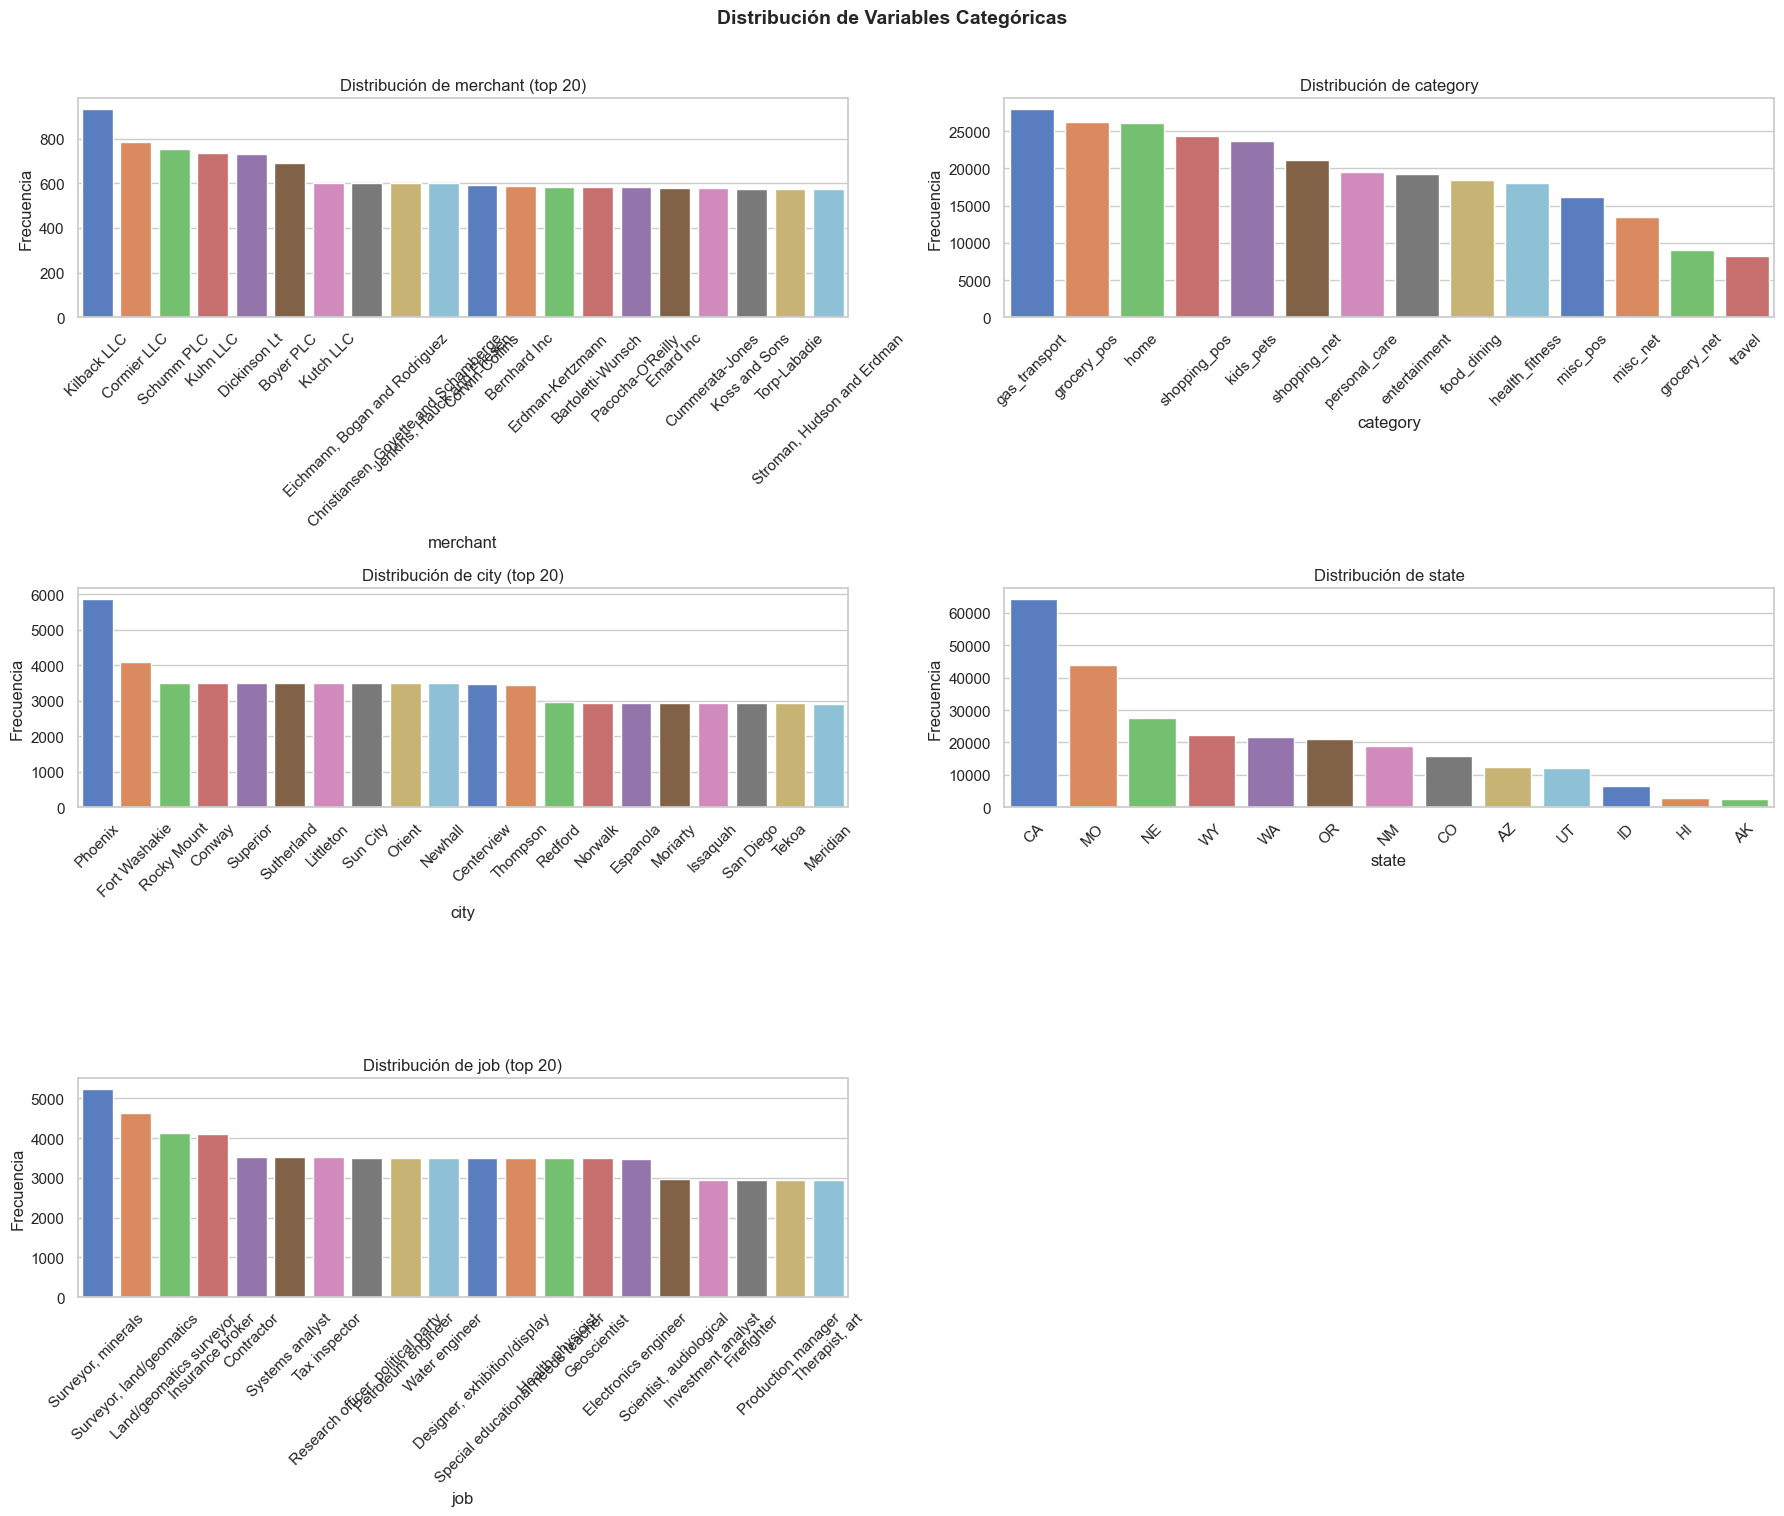

In [48]:
# Distribución de frecuencias (top 20 categorías para variables de alta cardinalidad)
df_fraud_vis = df.copy()
df_fraud_vis['is_fraud'] = df_fraud_vis['is_fraud'].map({0: 'Legítima', 1: 'Fraude'})

str_cols = df.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
nrows = len(str_cols) // 2 + len(str_cols) % 2
fig, axs = plt.subplots(nrows=nrows, ncols=2, figsize=(18, 5 * nrows))
axs = axs.flatten()

for i, col in enumerate(str_cols):
    top_cats = df_fraud_vis[col].value_counts().head(20).index
    df_plot  = df_fraud_vis[df_fraud_vis[col].isin(top_cats)]
    sns.countplot(data=df_plot, x=col, order=top_cats, ax=axs[i], palette='muted')
    axs[i].set_title(f'Distribución de {col}' +
                     (' (top 20)' if df[col].nunique() > 20 else ''))
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frecuencia')
    axs[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.suptitle('Distribución de Variables Categóricas', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> **Observación:** Las variables `merchant`, `city` y `job` presentan alta cardinalidad (cientos/miles de valores únicos). Esto condiciona la estrategia de encoding: se utilizará **BinaryEncoder** en lugar de One-Hot, que generaría un número de columnas inmanejable.

## 8. Análisis bivariable — Correlaciones numéricas

Utilizamos tres métricas complementarias:
- **Pearson:** Captura relaciones lineales.
- **Spearman:** Captura relaciones monótonas (también no lineales).
- **Información Mutua:** Detecta cualquier tipo de dependencia estadística.

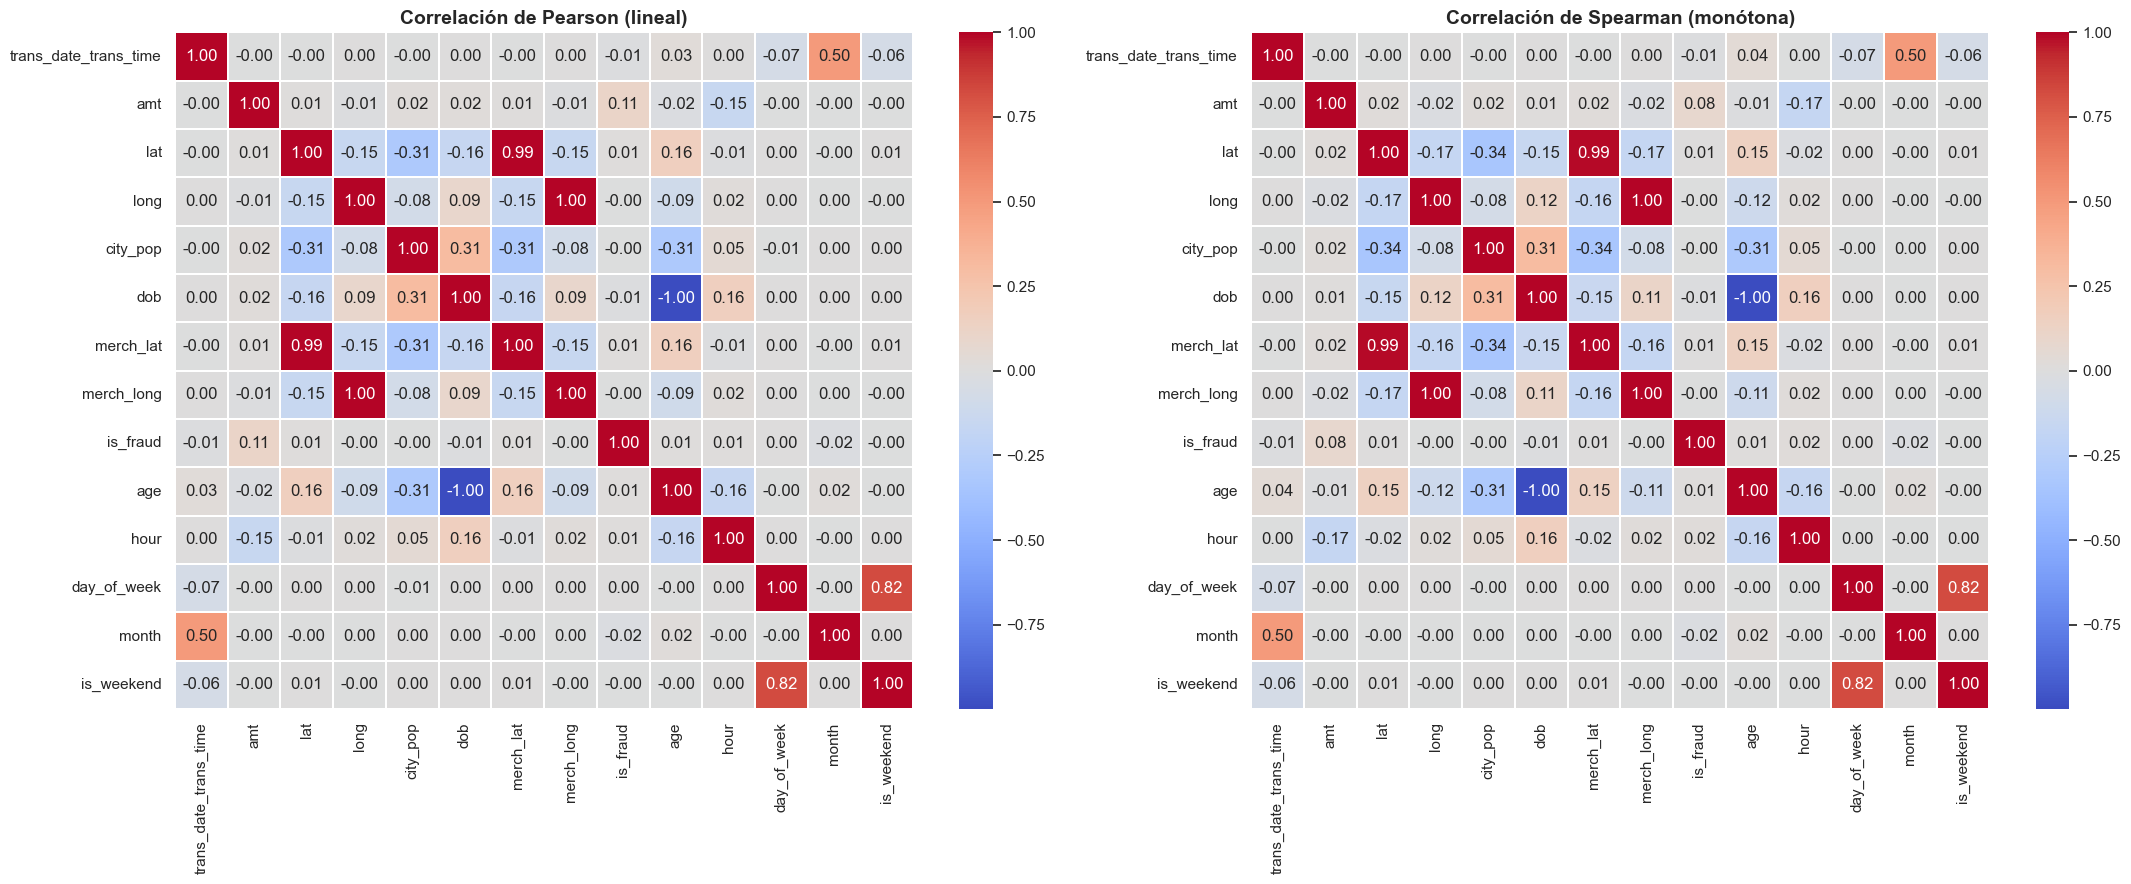

In [49]:
df_corr = df[numeric_cols].copy()
pearson_matrix  = df_corr.corr(method='pearson')
spearman_matrix = df_corr.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(pearson_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], cbar=True, linewidths=0.3)
axes[0].set_title('Correlación de Pearson (lineal)', fontsize=14, fontweight='bold')

sns.heatmap(spearman_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], cbar=True, linewidths=0.3)
axes[1].set_title('Correlación de Spearman (monótona)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [50]:
# Correlación de cada variable numérica con el target
print('--- Correlación con is_fraud (Pearson) ---')
print(pearson_matrix['is_fraud'].sort_values(ascending=False).drop('is_fraud').to_string())

print('\n--- Correlación con is_fraud (Spearman) ---')
print(spearman_matrix['is_fraud'].sort_values(ascending=False).drop('is_fraud').to_string())

--- Correlación con is_fraud (Pearson) ---
amt                      0.114336
hour                     0.013657
age                      0.012556
lat                      0.008845
merch_lat                0.008335
day_of_week              0.002217
is_weekend              -0.000710
city_pop                -0.000778
long                    -0.004472
merch_long              -0.004503
dob                     -0.013175
trans_date_trans_time   -0.014825
month                   -0.017131

--- Correlación con is_fraud (Spearman) ---
amt                      0.083914
hour                     0.022144
age                      0.012524
lat                      0.006963
merch_lat                0.006190
day_of_week              0.001855
city_pop                -0.000555
is_weekend              -0.000710
long                    -0.003499
merch_long              -0.003654
dob                     -0.013007
trans_date_trans_time   -0.014737
month                   -0.016700


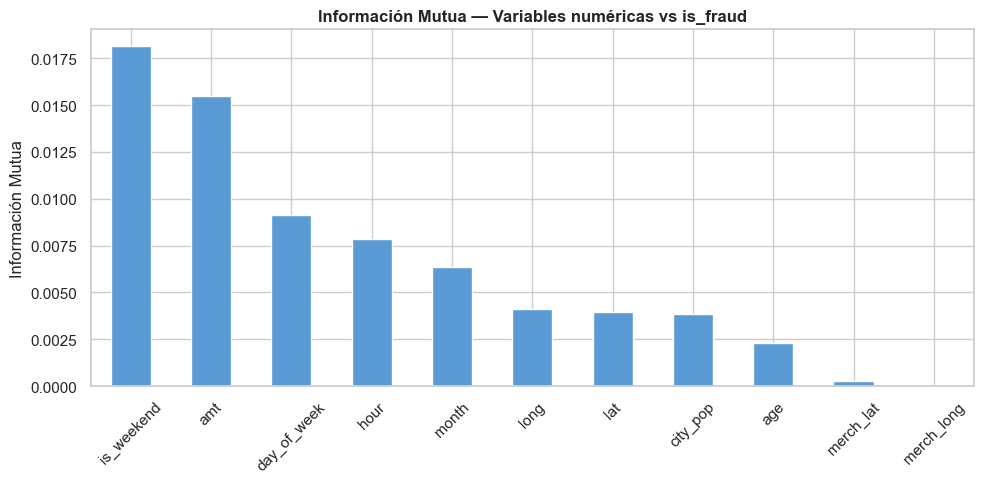


--- Ranking por Información Mutua ---
is_weekend     0.018125
amt            0.015492
day_of_week    0.009117
hour           0.007831
month          0.006371
long           0.004117
lat            0.003969
city_pop       0.003866
age            0.002323
merch_lat      0.000279
merch_long     0.000039


In [51]:
# Información Mutua — detecta dependencias no lineales
numeric_features_mi = df.select_dtypes(include=['int', 'float64']).drop(columns='is_fraud', errors='ignore')
target = df['is_fraud']

mi_scores = mutual_info_classif(numeric_features_mi, target, random_state=42)
mi_series = pd.Series(mi_scores, index=numeric_features_mi.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
mi_series.plot(kind='bar', ax=ax, color='#5B9BD5', edgecolor='white')
ax.set_title('Información Mutua — Variables numéricas vs is_fraud', fontweight='bold')
ax.set_ylabel('Información Mutua')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('\n--- Ranking por Información Mutua ---')
print(mi_series.to_string())

## 9. Análisis bivariable — Variables categóricas vs target

Para variables categóricas utilizamos:
- **Chi-cuadrado:** Test de independencia estadística (¿existe relación con el fraude?).
- **V de Cramer:** Mide la fuerza de esa asociación (0 = independiente, 1 = asociación perfecta).

In [52]:
# Test Chi-cuadrado
resultados_chi = []

for col in categoric_cols:
    contingency_table = pd.crosstab(df[col], df['is_fraud'])
    chi2, p, dof, _ = chi2_contingency(contingency_table)
    resultados_chi.append({
        'Variable': col,
        'Chi²': round(chi2, 2),
        'p-valor': f'{p:.4e}',
        'Relación con Fraude': 'SÍ (p < 0.05)' if p < 0.05 else 'NO'
    })

df_chi = pd.DataFrame(resultados_chi).sort_values('Chi²', ascending=False)
print('--- Análisis Chi-Cuadrado vs is_fraud ---')
print(df_chi.to_string(index=False))

--- Análisis Chi-Cuadrado vs is_fraud ---
Variable     Chi²     p-valor Relación con Fraude
    city 23476.21  0.0000e+00       SÍ (p < 0.05)
     job 21876.88  0.0000e+00       SÍ (p < 0.05)
merchant  1840.97 4.4057e-105       SÍ (p < 0.05)
category  1164.63 7.1808e-241       SÍ (p < 0.05)
   state    95.35  4.5107e-15       SÍ (p < 0.05)


--- Fuerza de Asociación (V de Cramer) ---
Variable  V de Cramer   Fuerza
    city       0.2929 Moderada
     job       0.2827 Moderada
category       0.0651    Débil
merchant       0.0650    Débil
   state       0.0175    Débil


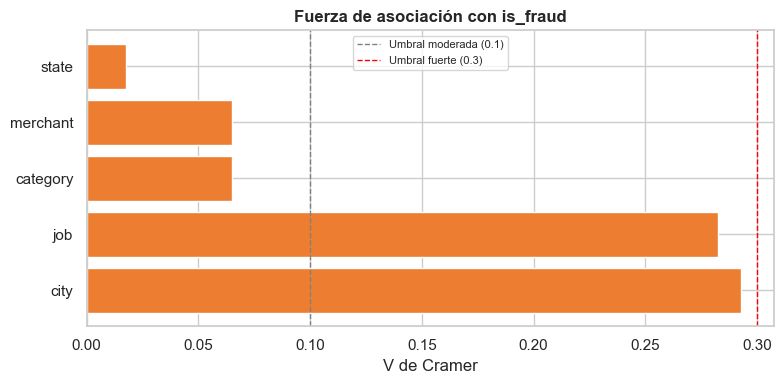

In [53]:
# V de Cramer — fuerza de asociación
def cramers_v(contingency_table):
    """Calcula el coeficiente V de Cramer para una tabla de contingencia."""
    chi2 = chi2_contingency(contingency_table)[0]
    n    = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

resultados_v = []
for col in categoric_cols:
    ct  = pd.crosstab(df[col], df['is_fraud'])
    v   = cramers_v(ct)
    if   v > 0.5: fuerza = 'Muy fuerte'
    elif v > 0.3: fuerza = 'Fuerte'
    elif v > 0.1: fuerza = 'Moderada'
    else:         fuerza = 'Débil'
    resultados_v.append({'Variable': col, 'V de Cramer': round(v, 4), 'Fuerza': fuerza})

df_cramer = pd.DataFrame(resultados_v).sort_values('V de Cramer', ascending=False)
print('--- Fuerza de Asociación (V de Cramer) ---')
print(df_cramer.to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(df_cramer['Variable'], df_cramer['V de Cramer'],
               color='#ED7D31', edgecolor='white')
ax.axvline(0.1, color='gray', linestyle='--', linewidth=1, label='Umbral moderada (0.1)')
ax.axvline(0.3, color='red',  linestyle='--', linewidth=1, label='Umbral fuerte (0.3)')
ax.set_xlabel('V de Cramer')
ax.set_title('Fuerza de asociación con is_fraud', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 10. Selección y eliminación de variables

Basándonos en el análisis anterior, eliminamos:

| Variable eliminada | Motivo |
|---|---|
| `trans_date_trans_time` | Sustituida por `hour`, `day_of_week`, `month`, `is_weekend` |
| `dob` | Sustituida por `age` |
| `lat`, `long`, `merch_lat`, `merch_long` | Baja información mutua; ruido geográfico |
| `city_pop` | Correlación casi nula con el target |
| `state` | V de Cramer bajo; `city` y `category` capturan mejor la variación geográfica/contextual |

In [54]:
cols_to_drop = ['state', 'trans_date_trans_time', 'dob',
                'city_pop', 'lat', 'long', 'merch_lat', 'merch_long']

df.drop(columns=[c for c in cols_to_drop if c in df.columns],           inplace=True)
df_test.drop(columns=[c for c in cols_to_drop if c in df_test.columns], inplace=True)

print('Columnas restantes en train:')
df.info()

Columnas restantes en train:
<class 'pandas.core.frame.DataFrame'>
Index: 271685 entries, 179685 to 109523
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   merchant     271685 non-null  object 
 1   category     271685 non-null  object 
 2   amt          271685 non-null  float64
 3   city         271685 non-null  object 
 4   job          271685 non-null  object 
 5   is_fraud     271685 non-null  int64  
 6   age          271685 non-null  int64  
 7   hour         271685 non-null  int32  
 8   day_of_week  271685 non-null  int32  
 9   month        271685 non-null  int32  
 10  is_weekend   271685 non-null  int64  
dtypes: float64(1), int32(3), int64(3), object(4)
memory usage: 21.8+ MB


## 11. Encoding y escalado final

Estrategia de encoding por tipo de variable:

| Variables | Técnica | Motivo |
|---|---|---|
| `merchant`, `city`, `job` | **BinaryEncoder** | Alta cardinalidad: reduce dimensiones de forma eficiente |
| `category` | **OneHotEncoding** | 14 categorías manejables; preserva interpretabilidad |
| `age`, `hour`, `day_of_week`, `month`, `is_weekend` | **RobustScaler** | Variables ordinales/continuas; robusto ante outliers |

> **Nota:** El `ColumnTransformer` aplica `fit` solo sobre los datos de entrenamiento y `transform` sobre el test, evitando data leakage.

In [55]:
columnas_features = [c for c in df.columns if c != 'is_fraud']
X_train_prep = df[columnas_features]
X_test_prep  = df_test[columnas_features]

binary_features  = ['merchant', 'city', 'job']
oh_features      = ['category']
numeric_features = ['age', 'hour', 'day_of_week', 'month', 'is_weekend']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(),                                              numeric_features),
        ('bin', BinaryEncoder(),                                             binary_features),
        ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False), oh_features)
    ],
    remainder='drop'
)

# fit_transform sobre train — transform sobre test
X_train_encoded = preprocessor.fit_transform(X_train_prep)
X_test_encoded  = preprocessor.transform(X_test_prep)

cols_names    = preprocessor.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_encoded, columns=cols_names)
X_test_final  = pd.DataFrame(X_test_encoded,  columns=cols_names)

print(f'Dimensiones finales — Train: {X_train_final.shape}, Test: {X_test_final.shape}')
print(f'Número de features finales: {X_train_final.shape[1]}')
X_train_final.head()

Dimensiones finales — Train: (271685, 45), Test: (67922, 45)
Número de features finales: 45


,num__age,num__hour,num__day_of_week,num__month,num__is_weekend,bin__merchant_0,bin__merchant_1,bin__merchant_2,bin__merchant_3,bin__merchant_4,...,oh__category_grocery_pos,oh__category_health_fitness,oh__category_home,oh__category_kids_pets,oh__category_misc_net,oh__category_misc_pos,oh__category_personal_care,oh__category_shopping_net,oh__category_shopping_pos,oh__category_travel
0,0.041667,-0.083333,0.50,-0.833333,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.583333,0.75,0.666667,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.541667,-0.333333,-0.75,-0.666667,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.791667,-0.666667,0.50,-0.500000,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.958333,-0.750000,-0.75,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 12. Guardado de los datasets procesados

In [56]:
# Reseteamos índices antes de concatenar (evita NaN por índices desalineados)
y_train_res = y_train.reset_index(drop=True)
y_test_res  = y_test.reset_index(drop=True)

df_train_encoded = pd.concat([X_train_final, y_train_res], axis=1)
df_test_encoded  = pd.concat([X_test_final,  y_test_res],  axis=1)

df_train_encoded.to_csv('../data/df_train.csv', index=False)
df_test_encoded.to_csv('../data/df_test.csv',   index=False)

print('Archivos guardados:')
print(f'  ../data/df_train.csv  →  {df_train_encoded.shape[0]:,} filas × {df_train_encoded.shape[1]} columnas')
print(f'  ../data/df_test.csv   →  {df_test_encoded.shape[0]:,} filas  × {df_test_encoded.shape[1]} columnas')

Archivos guardados:
  ../data/df_train.csv  →  271,685 filas × 46 columnas
  ../data/df_test.csv   →  67,922 filas  × 46 columnas


In [57]:
# Verificación de integridad — recargamos y comprobamos
df_train_check = pd.read_csv('../data/df_train.csv')
df_test_check  = pd.read_csv('../data/df_test.csv')

print('--- Verificación de los archivos guardados ---')
print(f'Train shape:  {df_train_check.shape}')
print(f'Test shape:   {df_test_check.shape}')
print(f'Nulos en train: {df_train_check.isnull().sum().sum()}')
print(f'Nulos en test:  {df_test_check.isnull().sum().sum()}')
print(f'\nDistribución del target en train:')
print(df_train_check['is_fraud'].value_counts(normalize=True).mul(100).round(2).to_string())
print(f'\nDistribución del target en test:')
print(df_test_check['is_fraud'].value_counts(normalize=True).mul(100).round(2).to_string())

--- Verificación de los archivos guardados ---
Train shape:  (271685, 46)
Test shape:   (67922, 46)
Nulos en train: 0
Nulos en test:  0

Distribución del target en train:
is_fraud
0    99.48
1     0.52

Distribución del target en test:
is_fraud
0    99.48
1     0.52


## Resumen del EDA

| Aspecto | Resultado |
|---|---|
| Registros totales | 339.607 |
| División train/test | 80% / 20% (estratificada) |
| Valores nulos | Ninguno |
| Desbalanceo | ~0.52% fraudes → tratar en modelado (SMOTE / class_weight) |
| Outliers | Tratados con log1p (amt, city_pop) y RobustScaler (coords) |
| Features eliminadas | 8 (fechas originales, coords, city_pop, state) |
| Features nuevas | 5 (age, hour, day_of_week, month, is_weekend) |
| Encoding | BinaryEncoder (alta cardinalidad) + OHE (category) |
| Features finales | ~46 columnas |
| Archivos de salida | `df_train.csv` y `df_test.csv` |